In [2]:
import cv2
import numpy as np

s = 0
video_cap = cv2.VideoCapture(s)

win_name = 'Camera Preview'
cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)

net = cv2.dnn.readNetFromCaffe('data/model/deploy.prototxt', 'data/model/res10_300x300_ssd_iter_140000.caffemodel')

mean = [104, 117, 123]
scale = 1.0
in_width = 300
in_height = 300

detection_threshold = 0.5

font_style = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
font_thickness = 1

In [3]:
while True:
    has_frame, frame = video_cap.read()
    if not has_frame:
        break
    h = frame.shape[0]
    w = frame.shape[1]

    frame = cv2.flip(frame, 1)

    blob = cv2.dnn.blobFromImage(frame, scale, (in_width, in_height), mean, False, False)

    net.setInput(blob)
    detections = net.forward()

    print(detections.shape, detections)
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > detection_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype('int')

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = 'Confidence: %.4f' % confidence
            label_size, base_line = cv2.getTextSize(label, font_style, font_scale, font_thickness)
            cv2.rectangle(frame, (x1, y1 - label_size[1]), (x1 + label_size[0], y1 + base_line), (255, 255, 255), cv2.FILLED)
            cv2.putText(frame, label, (x1, y1), font_style, font_scale, (0, 0, 0))

    cv2.imshow(win_name, frame)
    key = cv2.waitKey(1)
    if key == 27 or key == ord('q') or key == ord('Q'):
        break

(1, 1, 200, 7) [[[[0.         1.         0.99889034 ... 0.5562216  0.7092618
    1.0092115 ]
   [0.         1.         0.11776744 ... 0.12153208 0.9817931
    0.8723487 ]
   [0.         1.         0.11725646 ... 0.12482634 4.9787374
    0.8716384 ]
   ...
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]]]]
(1, 1, 200, 7) [[[[0.         1.         0.9995621  ... 0.54208815 0.72823495
    1.0075133 ]
   [0.         1.         0.11802816 ... 0.12510458 4.978547
    0.87131226]
   [0.         1.         0.11755972 ... 0.12149259 0.98298657
    0.87335134]
   ...
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]]]]
(1, 1, 200, 7) [[[[0.         1.         0.9996761  ...

KeyboardInterrupt: 

In [4]:
video_cap.release()
cv2.destroyAllWindows()

#### Application: Face Blurring

In [5]:
import matplotlib.pyplot as plt

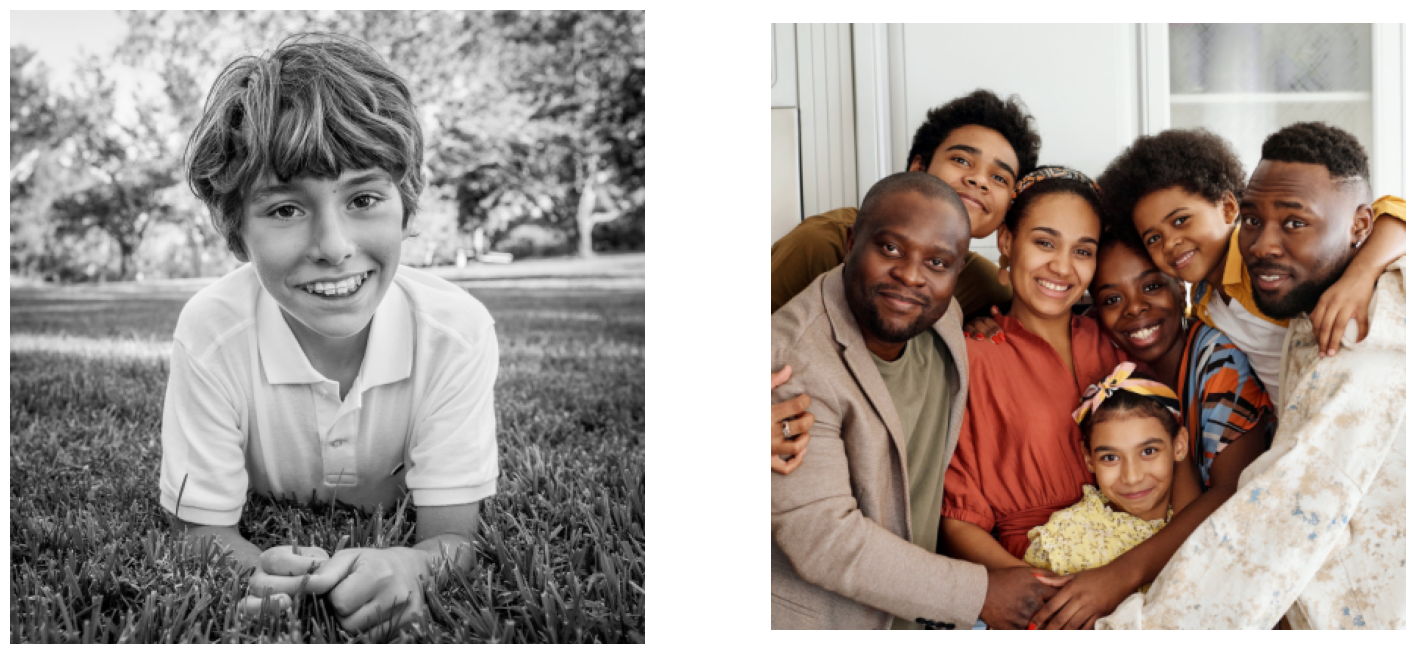

In [6]:
img1 = cv2.imread('data/images/boy.jpg', cv2.IMREAD_COLOR)
img2 = cv2.imread('data/images/family.jpg', cv2.IMREAD_COLOR)

fig = plt.figure(figsize=(18,10))

plt.subplot(1,2,1); plt.axis('off'); plt.imshow(img1[:,:,::-1])
plt.subplot(1,2,2); plt.axis('off'); plt.imshow(img2[:,:,::-1]);

In [7]:
net = cv2.dnn.readNetFromCaffe('data/model/deploy.prototxt', 'data/model/res10_300x300_ssd_iter_140000.caffemodel')

In [8]:
def blur(face, factor = 3):
    h, w = face.shape[:2]

    if factor < 1: factor = 1
    if factor > 5: factor = 5

    kW = int(w / factor)
    kH = int(h / factor)

    if kW % 2 == 0: kW += 1
    if kH % 2 == 0: kH += 1

    blurred = cv2.GaussianBlur(face, (int(kW), int(kH)), 0, 0)
    return blurred

In [9]:
def face_blur_rect(image, net, factor = 3):
    img = image.copy()

    blob = cv2.dnn.blobFromImage(img, scalefactor=1.0, size=(300, 300), mean=[104, 117, 123])

    net.setInput(blob)

    detections = net.forward()
    (h, w) = img.shape[:2]

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > detection_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype('int')
            face = img[y1:y2, x1:x2]
            face = blur(face, factor)

            img[y1:y2, x1:x2] = face

    return img

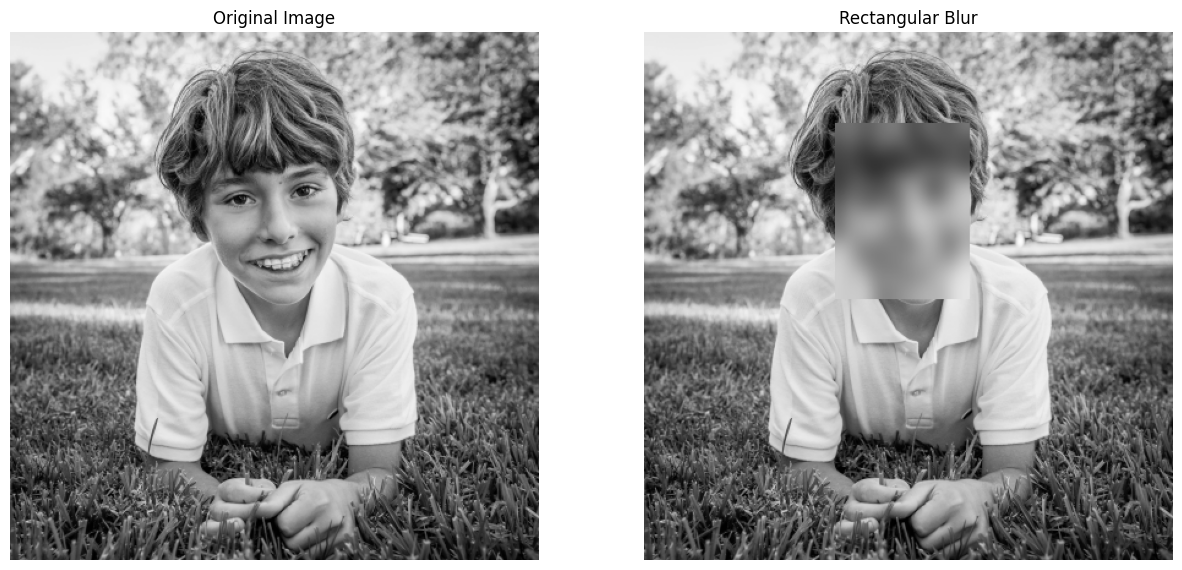

In [10]:
img1_rect = face_blur_rect(img1, net, factor=2.5)

fig = plt.figure(figsize=(15, 10))
plt.subplot(1,2,1); plt.axis('off'); plt.imshow(img1[:,:,::-1]);plt.title('Original Image')
plt.subplot(1,2,2); plt.axis('off'); plt.imshow(img1_rect[:,:,::-1]);plt.title('Rectangular Blur');

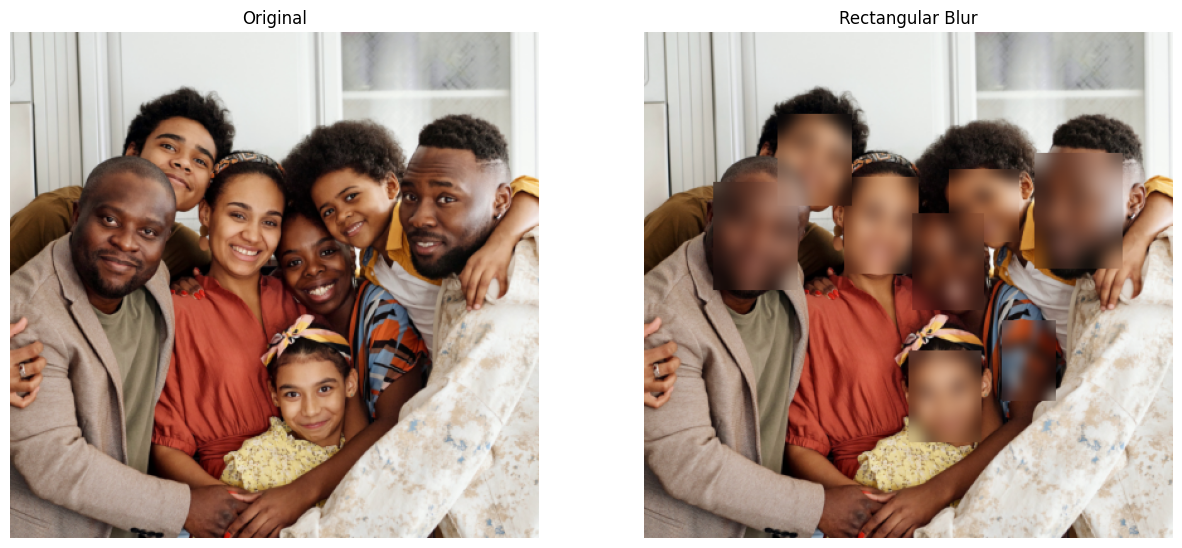

In [11]:
img2_rect = face_blur_rect(img2, net, factor=2)

fig = plt.figure(figsize=(15,10))
plt.subplot(1,2,1); plt.axis('off'); plt.imshow(img2[:,:,::-1]);      plt.title('Original')
plt.subplot(1,2,2); plt.axis('off'); plt.imshow(img2_rect[:,:,::-1]); plt.title('Rectangular Blur');

In [12]:
def face_blur_ellipse(image, net, factor=3, detect_threshold=0.90, write_mask=False):
    
    img = image.copy()
    img_blur = img.copy()
    
    elliptical_mask = np.zeros(img.shape, dtype=img.dtype)
    
    # Prepare image and perform inference.
    blob = cv2.dnn.blobFromImage(img, scalefactor=1.0, size=(300,300), mean=[104, 117, 123])
    net.setInput(blob)
    detections = net.forward()
    
    h, w = img.shape[:2]
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > detect_threshold:

            # Extract the bounding box coordinates from the detection.
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box

            # The face is defined by the bounding rectangle from the detection.
            face = img[int(y1):int(y2), int(x1):int(x2), :]
           
            # Blur the rectangular area defined by the bounding box.
            face = blur(face, factor=factor)

            # Copy the `blurred_face` to the blurred image.
            img_blur[int(y1):int(y2), int(x1):int(x2), :] = face
            
            # Specify the elliptical parameters directly from the bounding box coordinates.
            e_center = (x1 + (x2 - x1)/2, y1 + (y2 - y1)/2)
            e_size   = (x2 - x1, y2 - y1)
            e_angle  = 0.0
            
            # Create an elliptical mask. 
            elliptical_mask = cv2.ellipse(elliptical_mask, (e_center, e_size, e_angle), 
                                                      (255, 255, 255), -1, cv2.LINE_AA)  
            # Apply the elliptical mask
            np.putmask(img, elliptical_mask, img_blur)
            
    if write_mask:
        cv2.imwrite('data/images/elliptical_mask.jpg', elliptical_mask)

    return img

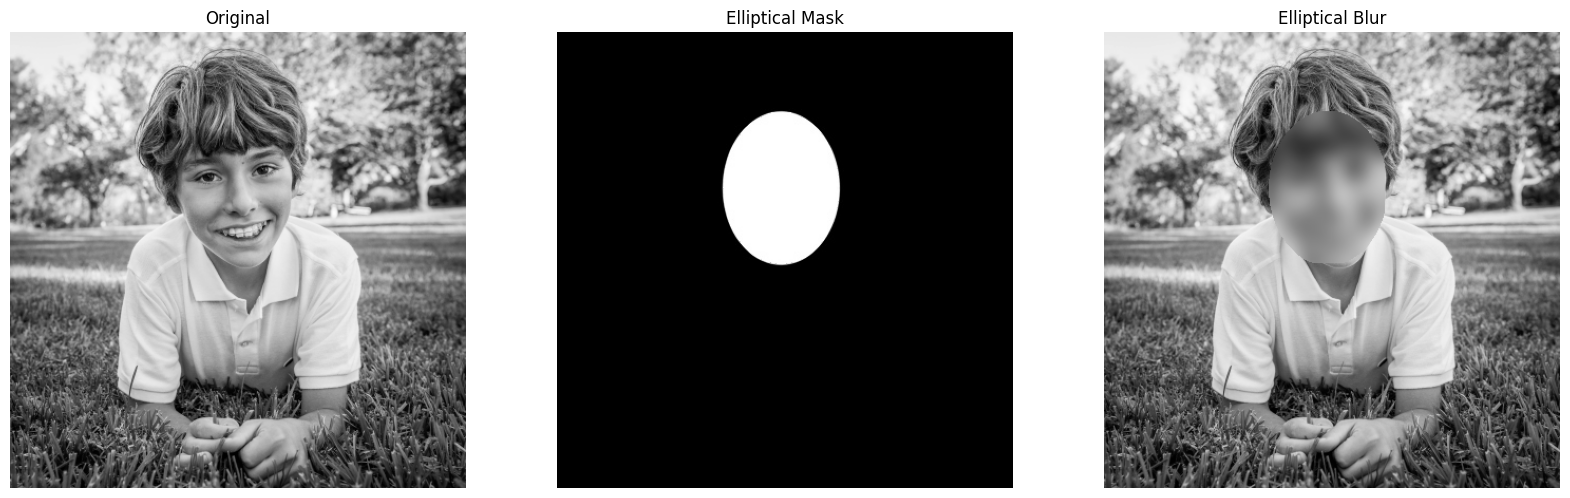

In [14]:
img1_ellipse = face_blur_ellipse(img1, net, factor=2.5, write_mask=True)

mask = cv2.imread('data/images/elliptical_mask.jpg')
fig = plt.figure(figsize=(20,10))
plt.subplot(1,3,1); plt.axis('off'); plt.imshow(img1[:,:,::-1]);         plt.title('Original')
plt.subplot(1,3,2); plt.axis('off'); plt.imshow(mask);                   plt.title('Elliptical Mask')
plt.subplot(1,3,3); plt.axis('off'); plt.imshow(img1_ellipse[:,:,::-1]); plt.title('Elliptical Blur');

Text(0.5, 1.0, 'Elliptical Blur')

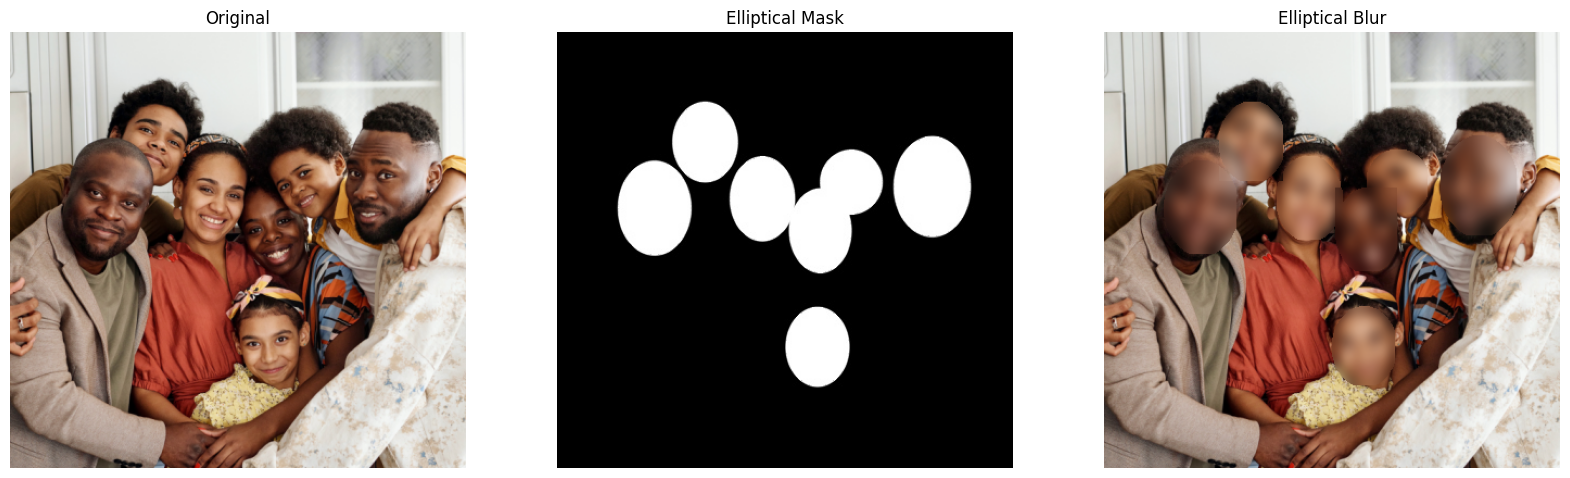

In [16]:
img2_ellipse = face_blur_ellipse(img2, net, factor=2, write_mask=True)

mask = cv2.imread('data/images/elliptical_mask.jpg')
fig = plt.figure(figsize=(20,10))
plt.subplot(1,3,1); plt.axis('off'); plt.imshow(img2[:,:,::-1]);         plt.title('Original')
plt.subplot(1,3,2); plt.axis('off'); plt.imshow(mask);                   plt.title('Elliptical Mask')
plt.subplot(1,3,3); plt.axis('off'); plt.imshow(img2_ellipse[:,:,::-1]); plt.title('Elliptical Blur')

In [17]:
def pixelate(roi, pixels=16):
    
    # Size of region to pixelate.
    roi_h, roi_w = roi.shape[:2]
    
    if roi_h > pixels and roi_w > pixels:
        # Resize input ROI to the (small) pixelated size.
        roi_small = cv2.resize(roi, (pixels, pixels), interpolation=cv2.INTER_LINEAR)

        # Now enlarge the pixelated ROI to fill the size of the original ROI.
        roi_pixelated = cv2.resize(roi_small, (roi_w, roi_h), interpolation=cv2.INTER_NEAREST)
    else:
        roi_pixelated = roi

    return roi_pixelated

In [18]:
def face_blur_pixelate(image, net, detection_threshold=0.9, pixels=10):
    img = image.copy()
    
    # Prepare image and perform inference.
    blob = cv2.dnn.blobFromImage(img, scalefactor=1.0, size=(300,300), mean=[104, 117, 123])
    net.setInput(blob)
    detections = net.forward()
    
    h, w = img.shape[:2]
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > detection_threshold:
            
            # Extract the bounding box coordinates from the detection.
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype("int")
            
            face = img[y1:y2, x1:x2]
            face = pixelate(face, pixels=pixels)
            img[y1:y2, x1:x2] = face
            
    return img

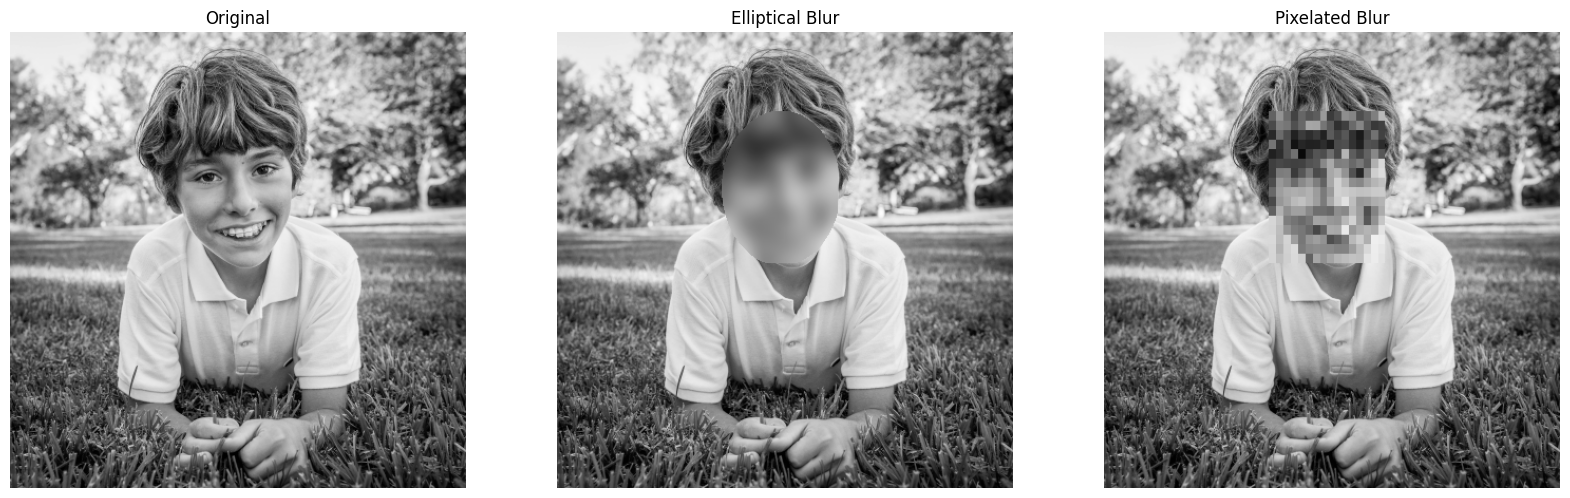

In [19]:
img1_pixel = face_blur_pixelate(img1, net, pixels=16)

fig = plt.figure(figsize=(20,10))
plt.subplot(1,3,1); plt.axis('off'); plt.imshow(img1[:,:,::-1]);         plt.title('Original')
plt.subplot(1,3,2); plt.axis('off'); plt.imshow(img1_ellipse[:,:,::-1]); plt.title('Elliptical Blur')
plt.subplot(1,3,3); plt.axis('off'); plt.imshow(img1_pixel[:,:,::-1]);   plt.title('Pixelated Blur');

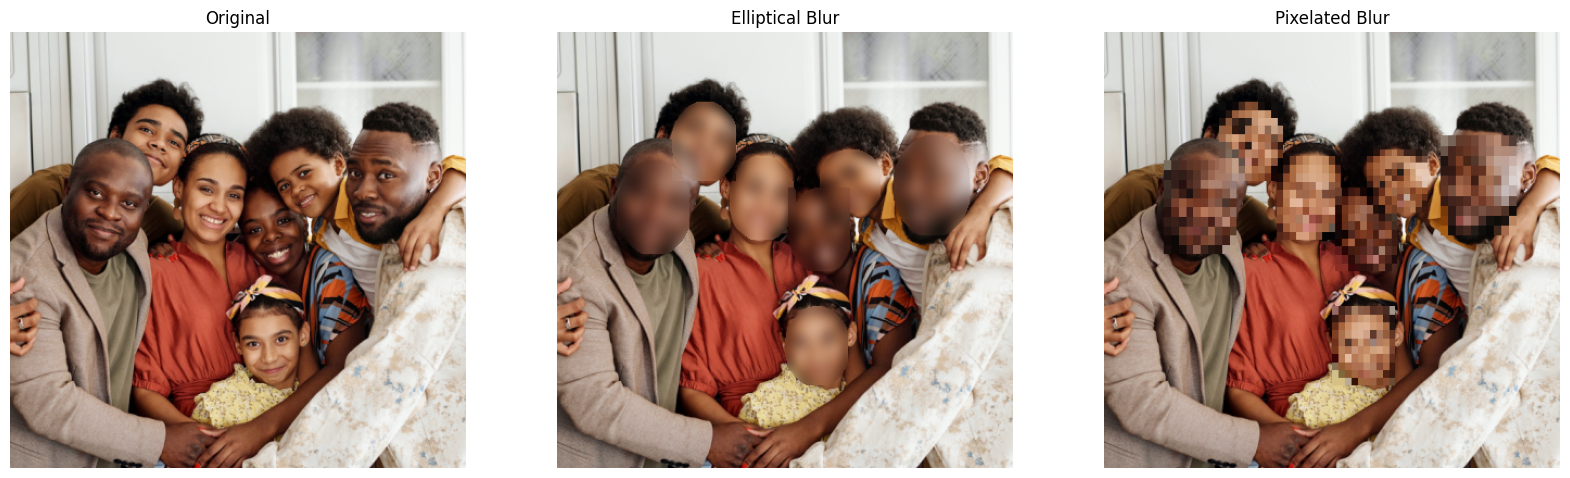

In [20]:
img2_pixel = face_blur_pixelate(img2, net, pixels=10)

fig = plt.figure(figsize=(20,10))
plt.subplot(1,3,1); plt.axis('off'); plt.imshow(img2[:,:,::-1]);         plt.title('Original')
plt.subplot(1,3,2); plt.axis('off'); plt.imshow(img2_ellipse[:,:,::-1]); plt.title('Elliptical Blur')
plt.subplot(1,3,3); plt.axis('off'); plt.imshow(img2_pixel[:,:,::-1]);   plt.title('Pixelated Blur');

In [21]:
def face_blur_ellipse_pixelate(image, net, detect_threshold=0.9, factor=3, pixels=10, write_mask=False):
    
    img = image.copy()
    img_out = img.copy()
    elliptical_mask = np.zeros(img.shape, dtype=img.dtype)
    
    # Prepare image and perform inference.
    blob = cv2.dnn.blobFromImage(img, scalefactor=1.0, size=(300,300), mean=[104, 117, 123])
    net.setInput(blob)
    detections = net.forward()
    
    h, w = img.shape[:2]
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > detect_threshold:

            # Extract the bounding box coordinates from the detection.
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box

            # The face is defined by the bounding rectangle from the detection.
            face = img[int(y1):int(y2), int(x1):int(x2), :]
            
            # Blur the rectangular area defined by the bounding box.
            face = blur(face, factor=factor)
            
            # Pixelate the blurred face.
            face = pixelate(face, pixels=pixels)

            # Copy the blurred/pixelated face to the output image.
            img_out[int(y1):int(y2), int(x1):int(x2), :] = face
            
            # Specify the elliptical parameters directly from the bounding box coordinates.
            e_center = (x1 + (x2 - x1)/2, y1 + (y2 - y1)/2)
            e_size   = (x2 - x1, y2 - y1)
            e_angle  = 0.0
            
            # Create an elliptical mask. 
            elliptical_mask = cv2.ellipse(elliptical_mask, (e_center, e_size, e_angle), 
                                                      (255, 255, 255), -1, cv2.LINE_AA)
            # Apply the elliptical mask.
            np.putmask(img, elliptical_mask, img_out)
            
    if write_mask:
        cv2.imwrite('elliptical_mask.jpg', elliptical_mask)
        
    return img

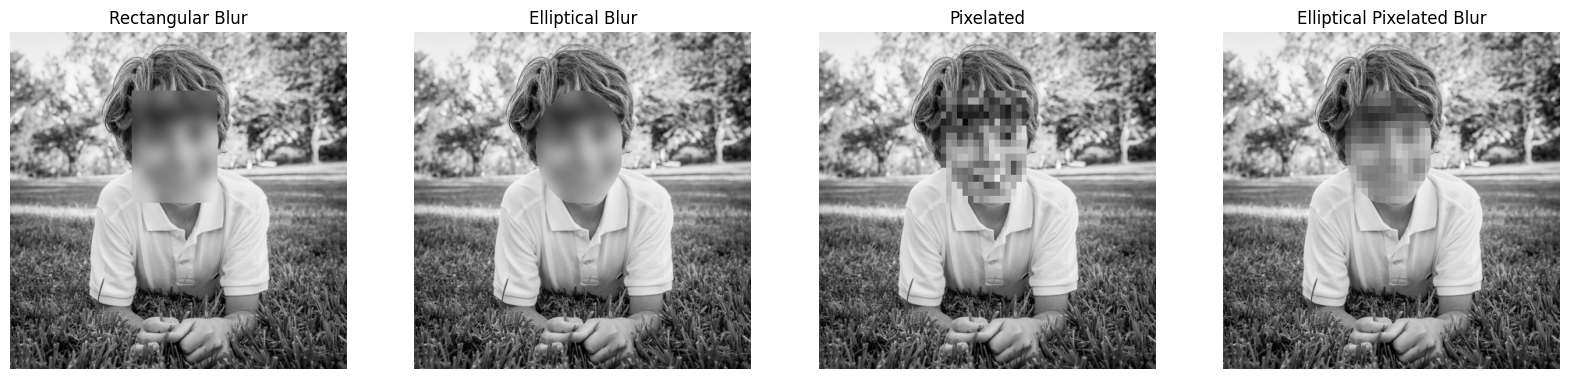

In [22]:
img1_epb = face_blur_ellipse_pixelate(img1, net, factor=3.5, pixels=15)

fig = plt.figure(figsize=(20,10))
plt.subplot(1,4,1); plt.axis('off'); plt.imshow(img1_rect[:,:,::-1]);    plt.title('Rectangular Blur')
plt.subplot(1,4,2); plt.axis('off'); plt.imshow(img1_ellipse[:,:,::-1]); plt.title('Elliptical Blur')
plt.subplot(1,4,3); plt.axis('off'); plt.imshow(img1_pixel[:,:,::-1]);   plt.title('Pixelated')
plt.subplot(1,4,4); plt.axis('off'); plt.imshow(img1_epb[:,:,::-1]);     plt.title('Elliptical Pixelated Blur');

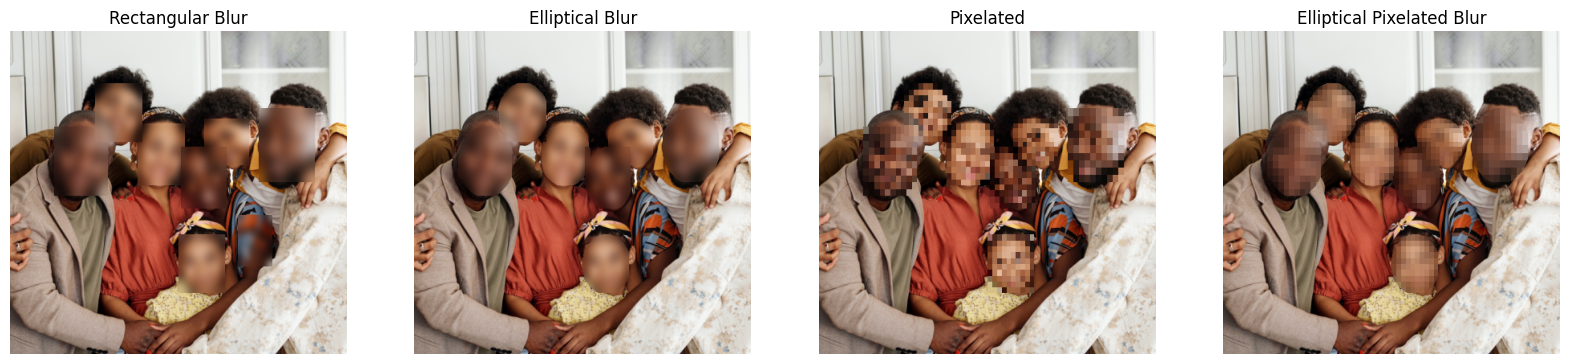

In [23]:
img2_epb = face_blur_ellipse_pixelate(img2, net, factor=2, pixels=10)

fig = plt.figure(figsize=(20,10))
plt.subplot(1,4,1); plt.axis('off'); plt.imshow(img2_rect[:,:,::-1]);    plt.title('Rectangular Blur')
plt.subplot(1,4,2); plt.axis('off'); plt.imshow(img2_ellipse[:,:,::-1]); plt.title('Elliptical Blur')
plt.subplot(1,4,3); plt.axis('off'); plt.imshow(img2_pixel[:,:,::-1]);   plt.title('Pixelated')
plt.subplot(1,4,4); plt.axis('off'); plt.imshow(img2_epb[:,:,::-1]);     plt.title('Elliptical Pixelated Blur');